# CAP 4633C — Assignment 1 (Spring 2026)
**Student:** Jessica Vargas  

All questions are based on the **Cancer (Breast Cancer)** dataset from `sklearn.datasets`.

**Important:** The outcome variable is defined exactly as instructed:
- `Y = 1` → Malignant tumor
- `Y = 0` → Benign tumor


In [1]:
# Imports
import numpy as np
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    make_scorer
)

import matplotlib.pyplot as plt


## Load the Cancer dataset

In [2]:
# Load the dataset exactly as instructed
cancer_data = datasets.load_breast_cancer()
cancer_df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

original_target = cancer_data.target
new_target = 1 - original_target

cancer_df['Y'] = new_target

cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Y
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [3]:
# Quick check: class counts (Y=1 malignant, Y=0 benign)
cancer_df['Y'].value_counts()

,count
Y,
0,357
1,212


## Train/Test split (ML approach)
- 80% training
- 20% testing
- `random_state=1` for reproducibility (class standard)

In [4]:
# Define predictors and outcome
X = cancer_df.drop(columns=['Y'])
y = cancer_df['Y']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1
)

X_train.shape, X_test.shape

((455, 30), (114, 30))

## Question 1 (40 points)
Obtain a classification tree using post-pruning via cost-complexity pruning (CCP) and cross-validation.

**Requirements:**
- Use the same steps as in class
- Use 80/20 split (already done)
- Grid search over **alpha** (`ccp_alpha`) and **criterion** (`gini` vs `entropy`)

In [5]:
# Q1: Build CCP alpha candidates from the training data
tree_base = DecisionTreeClassifier(random_state=1)
ccp_path = tree_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(ccp_path.ccp_alphas)

# Remove the largest alpha (usually collapses the tree to a single node)
ccp_alphas = ccp_alphas[:-1]

print('Number of CCP alphas:', len(ccp_alphas))
print('CCP alpha candidates:', ccp_alphas)

Number of CCP alphas: 9
CCP alpha candidates: [0.         0.00218915 0.003663   0.0043657  0.00646936 0.01253133
 0.01651845 0.0172666  0.03486461]


In [7]:
# Q1: GridSearchCV to select best (ccp_alpha, criterion)
cv_object = KFold(n_splits=3, shuffle=True, random_state=1)

hyperparam_grid_tree = {
    'ccp_alpha': ccp_alphas,
    'criterion': ['entropy', 'gini']
}

grid_search_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_grid=hyperparam_grid_tree,
    cv=cv_object,
    scoring='accuracy'
)

grid_search_tree.fit(X_train, y_train)

print('Best hyperparameters:', grid_search_tree.best_params_)
print('Best CV accuracy:', grid_search_tree.best_score_)

Best hyperparameters: {'ccp_alpha': np.float64(0.003663003663003663), 'criterion': 'gini'}
Best CV accuracy: 0.9273846868827699


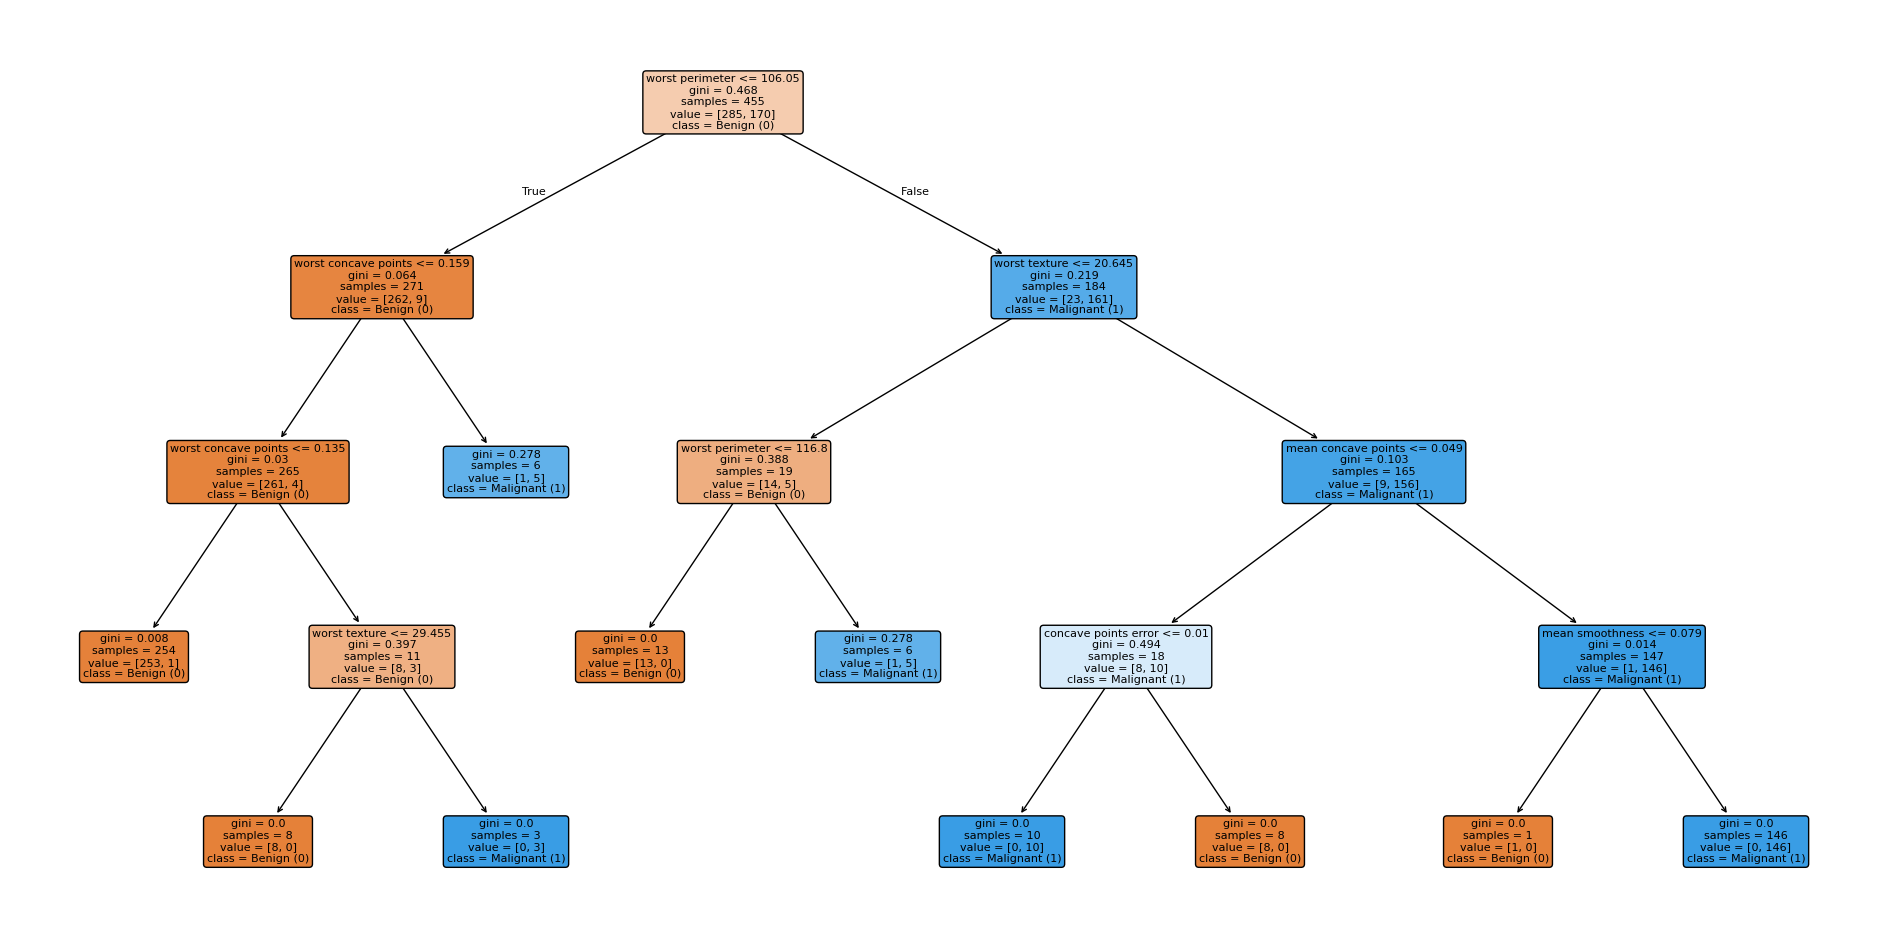

In [8]:
# Fit the chosen (best) tree on the training data (GridSearchCV refits by default)
best_tree = grid_search_tree.best_estimator_

# Plot the tree (figure required)
plt.figure(figsize=(24, 12))
plot_tree(
    best_tree,
    feature_names=list(X.columns),
    class_names=['Benign (0)', 'Malignant (1)'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

### Q1a) Rightmost leaf (from the tree figure)
We will extract the **rightmost leaf** by following the right child repeatedly from the root.

From the rightmost leaf, report:
- Number of observations (samples) that reached it
- Prediction of **Y** for samples that reached it, and **justify** using the leaf `value` (majority class).

In [9]:
# Helper: rightmost leaf info
def rightmost_leaf_info(dt_model):
    t = dt_model.tree_
    node = 0
    while t.children_right[node] != -1:
        node = t.children_right[node]
    leaf_node = node
    n_samples = t.n_node_samples[leaf_node]
    value_vec = t.value[leaf_node][0]
    classes = dt_model.classes_
    pred_class = classes[np.argmax(value_vec)]
    return leaf_node, n_samples, value_vec, pred_class

leaf_node, n_samples_right, value_vec_right, pred_right = rightmost_leaf_info(best_tree)

print('Rightmost leaf node index:', leaf_node)
print('Samples reaching rightmost leaf:', n_samples_right)
print('Leaf value vector (class distribution in order classes_):', value_vec_right)
print('classes_ order:', best_tree.classes_)
print('Predicted class at rightmost leaf (Y):', pred_right)

Rightmost leaf node index: 18
Samples reaching rightmost leaf: 146
Leaf value vector (class distribution in order classes_): [0. 1.]
classes_ order: [0 1]
Predicted class at rightmost leaf (Y): 1


**Answer Q1a (Justification):**  
The prediction at a leaf is the **majority class** in that leaf. The tree stores the leaf `value` vector in the order given by `tree.classes_`.  
Therefore, the predicted **Y** at the rightmost leaf is the class with the **largest** entry in the leaf `value` vector.

In [10]:
# Q1b) Test prediction error rate
y_pred_test_tree = best_tree.predict(X_test)

test_accuracy_tree = accuracy_score(y_test, y_pred_test_tree)
test_error_tree = 1 - test_accuracy_tree

print('Test accuracy (Tree):', test_accuracy_tree)
print('Test prediction error rate (Tree):', test_error_tree)

Test accuracy (Tree): 0.9473684210526315
Test prediction error rate (Tree): 0.052631578947368474


### Q1c) 350 new malignant people
If all 350 people are truly malignant (Y=1), the expected number correctly classified is:

**Expected correct = Sensitivity (Recall for Malignant) × 350**

We estimate sensitivity using the test set.

In [11]:
# Compute sensitivity (recall) for malignant class (Y=1)
recall_malignant_tree = recall_score(y_test, y_pred_test_tree, pos_label=1)
expected_correct_350 = recall_malignant_tree * 350

print('Sensitivity/Recall for malignant (Tree):', recall_malignant_tree)
print('Expected correctly classified among 350 malignant:', expected_correct_350)

Sensitivity/Recall for malignant (Tree): 0.9047619047619048
Expected correctly classified among 350 malignant: 316.6666666666667


### Q1d) Precision for the Malignant class (in %)
Precision (Malignant) = TP / (TP + FP).

We compute it on the test data and report it as a percentage.

In [12]:
# Precision for malignant class (Y=1)
precision_malignant_tree = precision_score(y_test, y_pred_test_tree, pos_label=1)
precision_malignant_tree_pct = 100 * precision_malignant_tree

print('Precision (malignant) as proportion:', precision_malignant_tree)
print('Precision (malignant) in %:', precision_malignant_tree_pct)

# Show confusion matrix for transparency
cm_tree = confusion_matrix(y_test, y_pred_test_tree, labels=[0,1])
print('\nConfusion Matrix (labels=[0,1]):')
print(cm_tree)
print('\nClassification report:')
print(classification_report(y_test, y_pred_test_tree, target_names=['Benign (0)','Malignant (1)']))

Precision (malignant) as proportion: 0.95
Precision (malignant) in %: 95.0

Confusion Matrix (labels=[0,1]):
[[70  2]
 [ 4 38]]

Classification report:
               precision    recall  f1-score   support

   Benign (0)       0.95      0.97      0.96        72
Malignant (1)       0.95      0.90      0.93        42

     accuracy                           0.95       114
    macro avg       0.95      0.94      0.94       114
 weighted avg       0.95      0.95      0.95       114



## Question 2 (20 points)
**Challenge question.** Use the same train/test split.

Fit a classification tree with the following *only* stopping criteria:
- `criterion = entropy`
- Tree depth cannot exceed **3 layers** (root + 2 layers)
- Each leaf must contain at least **10%** of the training observations

**Do not use any other stopping criteria.**

### Note on '3 layers'
In the class tree interpretation, a tree with **3 layers including the root** corresponds to **2 splits** along the longest path.
In `sklearn`, this is achieved with `max_depth=2`.

In [13]:
# Q2: Fit the constrained tree (ONLY the 3 criteria)
tree_q2 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=2,          # 3 layers including root
    min_samples_leaf=0.10,# at least 10% of training obs per leaf
    random_state=1
)

tree_q2.fit(X_train, y_train)
y_pred_test_q2 = tree_q2.predict(X_test)

test_accuracy_q2 = accuracy_score(y_test, y_pred_test_q2)
test_error_q2 = 1 - test_accuracy_q2

print('Test accuracy (Q2 tree):', test_accuracy_q2)
print('Test prediction error rate (Q2 tree):', test_error_q2)

Test accuracy (Q2 tree): 0.868421052631579
Test prediction error rate (Q2 tree): 0.13157894736842102


### Q2a) Compare to Question 1
The better classifier (based on test prediction error) is the one with **lower test error rate**.

In [14]:
# Comparison Q2a
print('Test error (Q1 tree):', test_error_tree)
print('Test error (Q2 tree):', test_error_q2)

if test_error_q2 < test_error_tree:
    print('Conclusion: Q2 tree is better (lower test error).')
else:
    print('Conclusion: Q1 tree is better (lower test error).')

Test error (Q1 tree): 0.052631578947368474
Test error (Q2 tree): 0.13157894736842102
Conclusion: Q1 tree is better (lower test error).


### Q2b) ONE metric combining Precision and Sensitivity (Malignant)
We report the **F1-score** for the malignant class.
- F1 combines precision and recall into one number.

In [15]:
# F1-score for malignant class (Y=1)
f1_malignant_q2 = f1_score(y_test, y_pred_test_q2, pos_label=1)
print('Metric name: F1-score (Malignant)')
print('F1-score value:', f1_malignant_q2)

Metric name: F1-score (Malignant)
F1-score value: 0.8192771084337349


### Q2c) 400 new people
Expected incorrect classifications = **(test error rate) × 400**

We use the test error rate from the Q2 tree as the estimate of misclassification probability.

In [16]:
# Expected incorrect among 400 new people using Q2 test error rate
expected_incorrect_400 = test_error_q2 * 400
print('Test error rate (Q2):', test_error_q2)
print('Expected incorrect among 400:', expected_incorrect_400)

Test error rate (Q2): 0.13157894736842102
Expected incorrect among 400: 52.63157894736841


## Question 3 (40 points)
Use the same train/test split.

### Q3a) Random Forest — GridSearchCV (Accuracy scoring)
**Requirements:**
- n_estimators: 100, 200, 300, 400, 500
- max_features: 10, 15, 20, 25
- criterion: entropy and gini
- Use **10 folds** in cross-validation
- Use **accuracy** as scoring
- Report number of **false negatives** on test data (malignant misclassified as benign).

In [17]:
# Q3a: Random Forest grid (accuracy scoring)
number_of_trees = np.array([100, 200, 300, 400, 500])
number_of_features = np.array([10, 15, 20, 25])
criterion_options = ['entropy', 'gini']

hyperparam_grid_rf = {
    'n_estimators': number_of_trees,
    'max_features': number_of_features,
    'criterion': criterion_options
}

cv_object_10 = KFold(n_splits=10, shuffle=True, random_state=1)

grid_search_rf_acc = GridSearchCV(
    estimator=RandomForestClassifier(random_state=1),
    param_grid=hyperparam_grid_rf,
    cv=cv_object_10,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_rf_acc.fit(X_train, y_train)

print('Best hyperparameters (Q3a, accuracy):', grid_search_rf_acc.best_params_)
print('Best CV accuracy:', grid_search_rf_acc.best_score_)

Best hyperparameters (Q3a, accuracy): {'criterion': 'entropy', 'max_features': np.int64(10), 'n_estimators': np.int64(200)}
Best CV accuracy: 0.9582125603864735


In [18]:
# Q3a: False negatives on the test set
best_rf_acc = grid_search_rf_acc.best_estimator_
y_pred_rf_acc = best_rf_acc.predict(X_test)

cm_rf_acc = confusion_matrix(y_test, y_pred_rf_acc, labels=[0,1])
TN, FP, FN, TP = cm_rf_acc.ravel()

print('Confusion matrix (labels=[0,1]):')
print(cm_rf_acc)
print('False negatives (malignant misclassified as benign):', FN)

Confusion matrix (labels=[0,1]):
[[72  0]
 [ 5 37]]
False negatives (malignant misclassified as benign): 5


### Q3b) Random Forest — GridSearchCV (Recall scoring for Malignant)
Repeat Q3a, but use **recall for the Malignant class** as the scoring metric.
Then compute false negatives again and compare to Q3a **only if** the chosen hyperparameters differ.

In [19]:
# Q3b: Grid search using recall for malignant (Y=1)
my_recall_scorer = make_scorer(recall_score, pos_label=1)

grid_search_rf_recall = GridSearchCV(
    estimator=RandomForestClassifier(random_state=1),
    param_grid=hyperparam_grid_rf,
    cv=cv_object_10,
    scoring=my_recall_scorer,
    n_jobs=-1
)

grid_search_rf_recall.fit(X_train, y_train)

print('Best hyperparameters (Q3b, recall):', grid_search_rf_recall.best_params_)
print('Best CV recall (malignant):', grid_search_rf_recall.best_score_)

Best hyperparameters (Q3b, recall): {'criterion': 'entropy', 'max_features': np.int64(15), 'n_estimators': np.int64(400)}
Best CV recall (malignant): 0.937572339940761


In [20]:
# Q3b: False negatives on the test set
best_rf_recall = grid_search_rf_recall.best_estimator_
y_pred_rf_recall = best_rf_recall.predict(X_test)

cm_rf_recall = confusion_matrix(y_test, y_pred_rf_recall, labels=[0,1])
TN2, FP2, FN2, TP2 = cm_rf_recall.ravel()

print('Confusion matrix (labels=[0,1]):')
print(cm_rf_recall)
print('False negatives (malignant misclassified as benign):', FN2)

Confusion matrix (labels=[0,1]):
[[72  0]
 [ 5 37]]
False negatives (malignant misclassified as benign): 5


In [22]:
# Compare Q3a vs Q3b only if the selected solutions differ
if grid_search_rf_acc.best_params_ != grid_search_rf_recall.best_params_:
    print("The chosen solutions are DIFFERENT.")
    print("FN (Q3a accuracy):", FN)
    print("FN (Q3b recall):", FN2)
    if FN2 < FN:
        print("Conclusion: False negatives REDUCED in Q3b compared to Q3a.")
    else:
        print("Conclusion: False negatives did NOT reduce in Q3b compared to Q3a.")
else:
    pass  # ELSE: do not report anything (per instructions)

The chosen solutions are DIFFERENT.
FN (Q3a accuracy): 5
FN (Q3b recall): 5
Conclusion: False negatives did NOT reduce in Q3b compared to Q3a.
